<a href="https://colab.research.google.com/github/annisaarc/superstore-sales-analysis/blob/main/analisis_prediksi_penjualan_dan_profitabilitas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Prediksi Kinerja Penjualan & Profitabilitas (Superstore)

## Pertanyaan Bisnis
1. **Pertanyaan 1 (Tren Musiman):** Berdasarkan histori data, bagaimana tren *total sales* bulanan perusahaan, dan apakah terdapat pola lonjakan pesanan yang konsisten pada periode kuartal tertentu?
2. **Pertanyaan 2 (Evaluasi Profitabilitas):** Dari seluruh sub-kategori produk, produk manakah yang menjadi penyumbang *profit* tertinggi, dan produk mana yang justru membakar modal perusahaan secara konsisten?

## Data Dictionary
| Kolom | Deskripsi |
| :--- | :--- |
| **order_date** | Tanggal pesanan dilakukan oleh pelanggan. |
| **segment** | Segmen target pasar (Consumer, Corporate, Home Office). |
| **category** | Kategori utama produk (Furniture, Office Supplies, Technology). |
| **sub_category** | Sub-kategori spesifik produk (misal: Chairs, Phones). |
| **sales** | Total pendapatan kotor dari transaksi (USD). |
| **profit** | Keuntungan bersih dari transaksi (USD). |

## Importing Library

In [2]:
import pandas as pd
import numpy as np
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [3]:
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")
files = os.listdir(path)

df = pd.read_csv(f"{path}/{files[0]}", encoding='windows-1252')
df.head()

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Assessing Data

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


**Hasil Identifikasi (*Assessing*):**
* **Struktur:** Data terdiri dari 9.994 baris dan 21 kolom tanpa *missing values* eksplisit.
* **Tipe Data:** Kolom `Order Date` masih berupa objek/string. Harus diubah ke format `datetime` untuk analisis *time-series*.
* **Statistik Finansial:** Ditemukan anomali di mana nilai *profit* minimum menyentuh angka ekstrem minus ($ -6599.97). Perlu diselidiki pada tahap analisis.

### Cleaning Data

In [13]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '_')

df['order_date'] = pd.to_datetime(df['order_date'])
df['month_year'] = df['order_date'].dt.to_period('M')
df['profit_status'] = np.where(df['profit'] > 0, 'Untung',
                               np.where(df['profit'] < 0, 'Rugi', 'BEP'))
df[['order_date', 'month_year', 'profit', 'profit_status']].head()

,order_date,month_year,profit,profit_status
0,2016-11-08,2016-11,41.9136,Untung
1,2016-11-08,2016-11,219.5820,Untung
2,2016-06-12,2016-06,6.8714,Untung
3,2015-10-11,2015-10,-383.0310,Rugi
4,2015-10-11,2015-10,2.5164,Untung


## Exploratory Data Analysis (EDA)

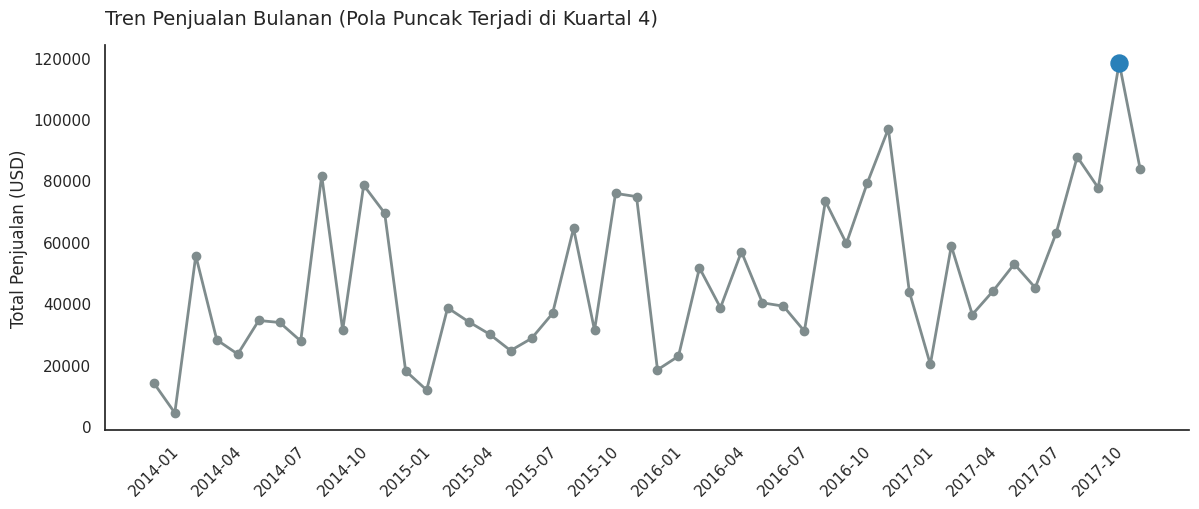

In [14]:
# Menjawab Pertanyan Bisnis 1: Tren Penjualan Musiman

sns.set_theme(style="white")
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Agregasi data penjualan bulanan
trend_df = df.groupby('month_year')['sales'].sum().reset_index()
trend_df['month_year'] = trend_df['month_year'].astype(str)

plt.figure(figsize=(14, 5))

plt.plot(trend_df['month_year'], trend_df['sales'], color='#7F8C8D', linewidth=2, marker='o')

max_sales_idx = trend_df['sales'].idxmax()
plt.scatter(trend_df.iloc[max_sales_idx]['month_year'], trend_df.iloc[max_sales_idx]['sales'],
            color='#2980B9', s=150, zorder=5)

plt.title('Tren Penjualan Bulanan (Pola Puncak Terjadi di Kuartal 4)', fontsize=14, loc='left', pad=15)
plt.xticks(np.arange(0, len(trend_df), 3), rotation=45)
plt.ylabel('Total Penjualan (USD)')
plt.show()

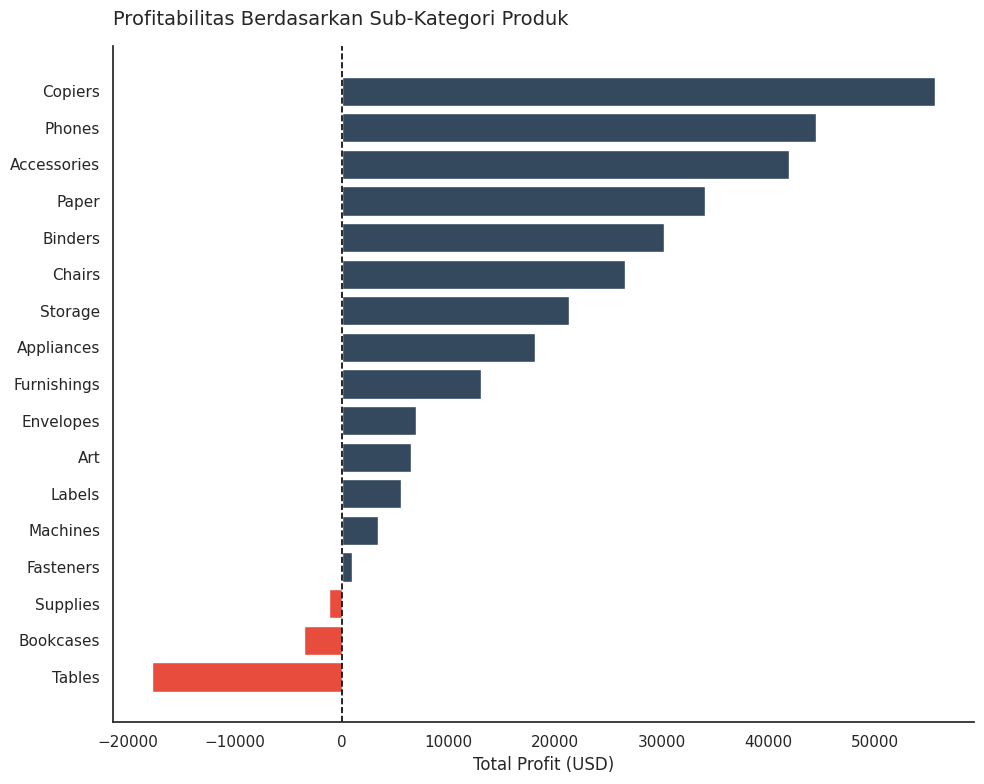

In [15]:
# Menjawab Pertanyaan Bisnis 2: Evaluasi Profitabilitas Produk

# Agregasi profit berdasarkan sub-kategori
profit_df = df.groupby('sub_category')['profit'].sum().sort_values(ascending=True).reset_index()

plt.figure(figsize=(10, 8))

colors = np.where(profit_df['profit'] < 0, '#E74C3C', '#34495E')

plt.barh(profit_df['sub_category'], profit_df['profit'], color=colors)

plt.title('Profitabilitas Berdasarkan Sub-Kategori Produk', fontsize=14, loc='left', pad=15)
plt.xlabel('Total Profit (USD)')
plt.axvline(0, color='black', linewidth=1.2, linestyle='--') # Garis BEP (Break Even Point)
plt.tight_layout()
plt.show()

## Kesimpulan & Actionable Insights

Berdasarkan *Exploratory Data Analysis* (EDA) yang telah dilakukan, ditarik beberapa simpulan dan rekomendasi bisnis berikut:

**Kesimpulan Utama:**
1. **Musiman yang Konsisten:** Kinerja penjualan memiliki ritme yang dapat diprediksi. Titik puncak (*peak season*) selalu berada di Kuartal 4 (Q4), khususnya pada rentang bulan November hingga Desember.
2. **Kesenjangan Profitabilitas:** Tidak semua produk dengan angka penjualan tinggi menghasilkan profit. Kategori *Copiers* dan *Phones* menjadi mesin pencetak uang utama. Namun, produk *Tables* dan *Bookcases* terbukti membebani margin perusahaan dengan kerugian finansial yang signifikan.

**Rekomendasi Bisnis:**
* Manajemen logistik wajib menyiapkan alokasi stok maksimal untuk produk *Technology* sebelum memasuki bulan Oktober untuk menangkap lonjakan pasar di akhir tahun.
* Segera lakukan audit biaya untuk lini *Tables* dan *Bookcases*. Sangat direkomendasikan untuk membekukan program diskon pada produk-produk merah tersebut untuk menambal kebocoran profit.